# Speech Emotion Detection — RAVDESS (Kaggle)

This notebook implements the machine-learning portion of the Hexovate assessment: dataset discovery, four-class filtering, audio exploration, MFCC-based features, actor-independent model selection, and a final held-out evaluation.

**Important:** actors 1–18 are used for group-aware cross-validation and final training; actors 19–24 are kept untouched until final testing. The notebook does not promise a score in advance: the printed test accuracy and macro-F1 are the actual results for those unseen actors.

The dashboard and online deployment are intentionally not included; this notebook-only version follows the requested scope.

## 1. Add the dataset in Kaggle

Create or open a Kaggle Notebook, then use **Add Input** and attach the dataset **uwrfkaggler/ravdess-emotional-speech-audio**. The next cell searches Kaggle's input folders recursively, so you do not need to hard-code the nested folder name. Internet access is not required if the dataset is attached and the standard packages are already present.

The notebook reads WAV filenames using the RAVDESS convention: the third filename field is the emotion code and the last field is the actor ID. It keeps only neutral (01), happy (03), sad (04), and angry (05).

In [20]:
# Install only packages that are actually missing (Kaggle usually has these already).
import importlib.util
import subprocess
import sys

required_packages = {
    "librosa": "librosa",
    "soundfile": "soundfile",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
    "tqdm": "tqdm",
}
missing = [package for module, package in required_packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are available.")

All required packages are available.


In [21]:
from pathlib import Path
import random
import warnings

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

SAMPLE_RATE = 22_050
EMOTION_CODES = {"01": "neutral", "03": "happy", "04": "sad", "05": "angry"}
EMOTION_ORDER = ["neutral", "happy", "sad", "angry"]
print("librosa:", librosa.__version__)
print("NumPy:", np.__version__)

librosa: 0.11.0
NumPy: 2.1.3


In [22]:
# Find WAV files recursively and parse the seven RAVDESS fields.
import re

search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path.cwd()]
all_wav_paths = set()
for root in search_roots:
    if root.exists():
        all_wav_paths.update(path for path in root.rglob("*")
                             if path.is_file() and path.suffix.lower() == ".wav")

records = []
unmatched_names = []
# RAVDESS uses seven 2-digit fields. Accept hyphens, underscores, or spaces,
# and tolerate a prefix/suffix around the seven fields.
ravdess_pattern = re.compile(r"(?<!\d)(\d{2}(?:[-_ ]\d{2}){6})(?!\d)")
for path in sorted(all_wav_paths):
    match = ravdess_pattern.search(path.stem)
    if not match:
        unmatched_names.append(path.name)
        continue
    fields = re.split(r"[-_ ]", match.group(1))
    # Keep audio-only speech clips: modality 03, vocal channel 01.
    if fields[0] != "03" or fields[1] != "01":
        continue
    emotion_code = fields[2]
    if emotion_code not in EMOTION_CODES:
        continue
    try:
        actor_id = int(fields[6])
    except (ValueError, IndexError):
        unmatched_names.append(path.name)
        continue
    records.append({
        "path": str(path),
        "filename": path.name,
        "emotion_code": emotion_code,
        "emotion": EMOTION_CODES[emotion_code],
        "actor_id": actor_id,
    })

if not records:
    sample_names = [path.name for path in sorted(all_wav_paths)[:12]]
    if not all_wav_paths:
        raise FileNotFoundError(
            "No WAV files found under /kaggle/input. In Kaggle, click Add Input and "
            "attach uwrfkaggler/ravdess-emotional-speech-audio."
        )
    raise ValueError(
        f"Found {len(all_wav_paths)} WAV file(s), but none matched RAVDESS's seven-field "
        f"audio-only speech filename format (modality 03, vocal channel 01) with emotion codes 01/03/04/05. Sample filenames: {sample_names}. "
        "Check that the attached input is the RAVDESS speech-audio dataset."
    )

metadata = pd.DataFrame(records, columns=["path", "filename", "emotion_code", "emotion", "actor_id"])
rows_before_dedup = len(metadata)
metadata = metadata.drop_duplicates(subset="filename").sort_values(
    ["actor_id", "emotion", "path"]
).reset_index(drop=True)
print(f"Duplicate copies skipped by filename: {rows_before_dedup - len(metadata)}")

print(f"WAV files scanned: {len(all_wav_paths)}")
print(f"Filtered RAVDESS clips found: {len(metadata)} (the task sheet expects 672)")
print(f"Actors found: {metadata['actor_id'].nunique()} — "
      f"{sorted(metadata['actor_id'].unique().tolist())}")
print("Emotion counts:")
display(metadata["emotion"].value_counts().reindex(EMOTION_ORDER, fill_value=0).rename("clips").to_frame())
print("Actor-wise clip counts:")
display(pd.crosstab(metadata["actor_id"], metadata["emotion"]).reindex(columns=EMOTION_ORDER, fill_value=0))

Duplicate copies skipped by filename: 672
WAV files scanned: 2880
Filtered RAVDESS clips found: 672 (the task sheet expects 672)
Actors found: 24 — [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Emotion counts:


,clips
emotion,
neutral,96
happy,192
sad,192
angry,192


Actor-wise clip counts:


emotion,neutral,happy,sad,angry
actor_id,,,,
1,4,8,8,8
2,4,8,8,8
3,4,8,8,8
4,4,8,8,8
5,4,8,8,8
6,4,8,8,8
7,4,8,8,8
8,4,8,8,8
9,4,8,8,8


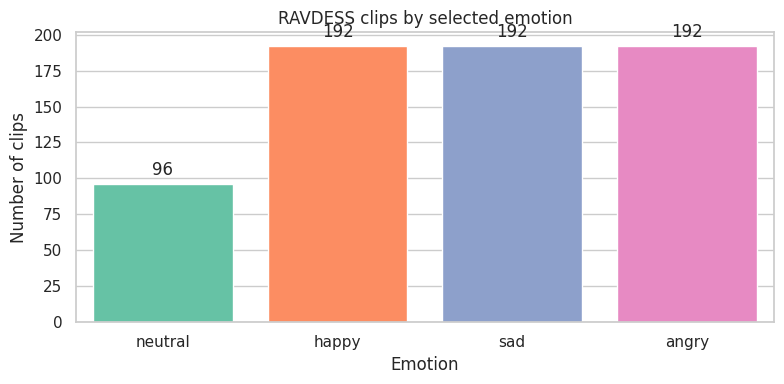

In [24]:
# A quick count plot makes the smaller neutral class visible.
counts = metadata["emotion"].value_counts().reindex(EMOTION_ORDER, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values, color="#6d8fc7", ax=ax)
for patch, color in zip(ax.patches, sns.color_palette("Set2", len(counts))):
    patch.set_facecolor(color)
ax.set(title="RAVDESS clips by selected emotion", xlabel="Emotion", ylabel="Number of clips")
for bar, value in zip(ax.patches, counts.values):
    ax.annotate(str(value), (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", xytext=(0, 4), textcoords="offset points")
plt.tight_layout()
plt.show()

## 2. Waveforms and Mel spectrograms

The plot shows one real clip for each selected emotion. A Mel spectrogram represents how audio energy changes across perceptual frequency bands over time.

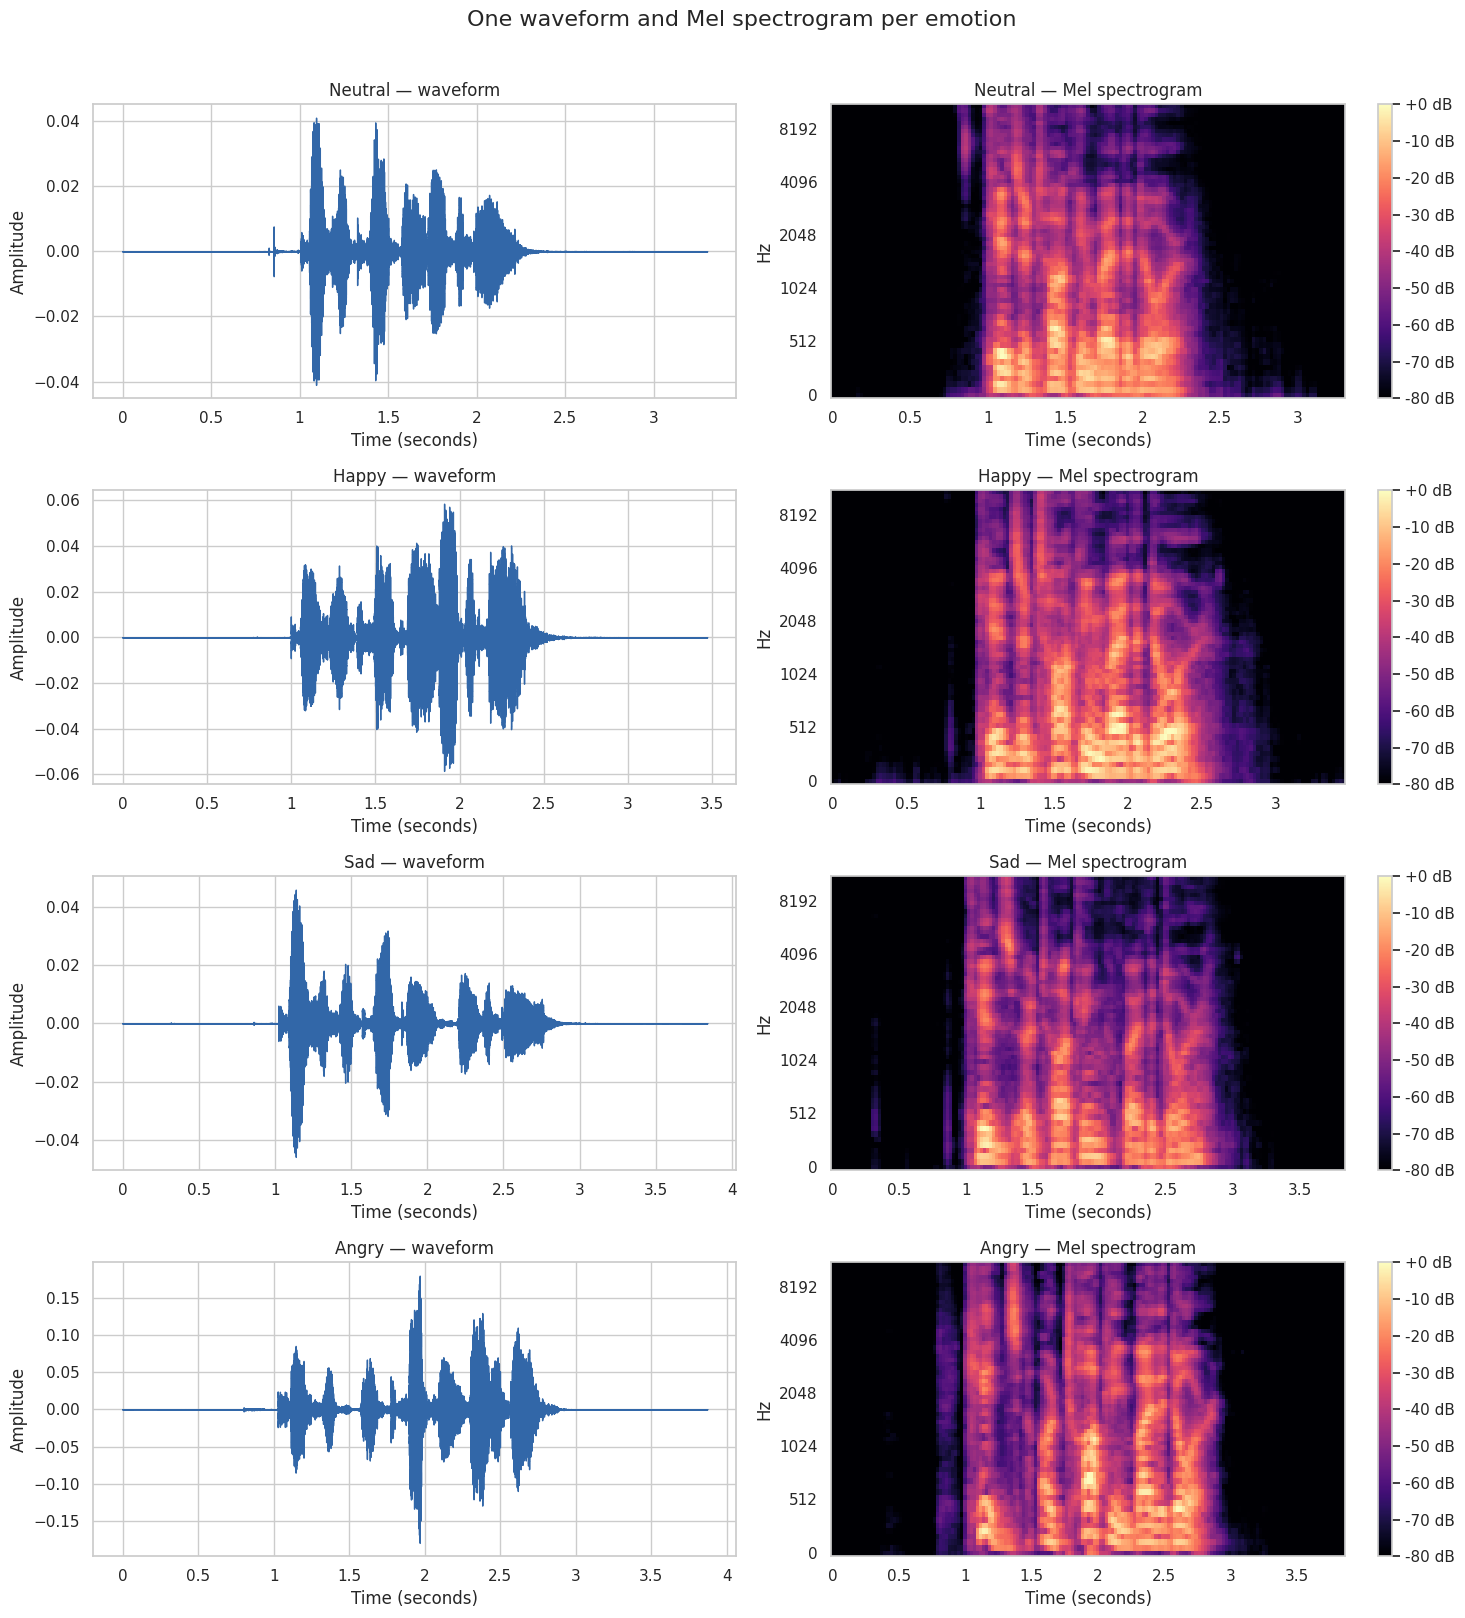

In [25]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 16))
for row, emotion in enumerate(EMOTION_ORDER):
    sample = metadata.loc[metadata["emotion"] == emotion].iloc[0]
    signal, sr = librosa.load(sample["path"], sr=SAMPLE_RATE, mono=True)
    time = np.arange(len(signal)) / sr
    librosa.display.waveshow(signal, sr=sr, ax=axes[row, 0], color="#3267a8")
    axes[row, 0].set(title=f"{emotion.title()} — waveform", xlabel="Time (seconds)", ylabel="Amplitude")

    mel_power = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=2048,
                                               hop_length=512, n_mels=64)
    mel_db = librosa.power_to_db(mel_power, ref=np.max)
    image = librosa.display.specshow(mel_db, sr=sr, hop_length=512,
                                     x_axis="time", y_axis="mel", cmap="magma",
                                     ax=axes[row, 1])
    axes[row, 1].set(title=f"{emotion.title()} — Mel spectrogram", xlabel="Time (seconds)")
    fig.colorbar(image, ax=axes[row, 1], format="%+2.0f dB")
fig.suptitle("One waveform and Mel spectrogram per emotion", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 3. Extract clip-level audio features

Each WAV is converted to mono at 22,050 Hz. Features include the mean and standard deviation of 40 MFCCs, MFCC deltas, chroma and log-Mel bands, plus compact spectral summaries. Mean-and-variation pooling gives one fixed-length row per clip. The scaler is fitted inside the SVM pipeline, separately within each cross-validation fold, to prevent information leakage.

In [26]:
def summarize_over_time(values):
    """Return per-feature mean followed by standard deviation over time."""
    values = np.asarray(values)
    if values.ndim == 1:
        values = values.reshape(1, -1)
    return np.concatenate([values.mean(axis=1), values.std(axis=1)])


def extract_audio_features(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
    if y.size < 2048:
        y = np.pad(y, (0, 2048 - y.size))

    n_fft, hop = 2048, 512
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40, n_fft=n_fft, hop_length=hop)
    delta_mfcc = librosa.feature.delta(mfcc, order=1)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    mel_db = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft,
                                       hop_length=hop, n_mels=64),
        ref=np.max,
    )
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    spectral_summary = np.vstack([
        librosa.feature.rms(y=y, frame_length=n_fft, hop_length=hop)[0],
        librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop)[0],
        librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop)[0],
        librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop)[0],
        librosa.feature.zero_crossing_rate(y, frame_length=n_fft, hop_length=hop)[0],
    ])
    return np.concatenate([
        summarize_over_time(mfcc),
        summarize_over_time(delta_mfcc),
        summarize_over_time(chroma),
        summarize_over_time(mel_db),
        summarize_over_time(contrast),
        summarize_over_time(spectral_summary),
    ])

feature_names = (
    [f"mfcc_mean_{i:02d}" for i in range(40)] + [f"mfcc_std_{i:02d}" for i in range(40)]
    + [f"delta_mfcc_mean_{i:02d}" for i in range(40)] + [f"delta_mfcc_std_{i:02d}" for i in range(40)]
    + [f"chroma_mean_{i:02d}" for i in range(12)] + [f"chroma_std_{i:02d}" for i in range(12)]
    + [f"logmel_mean_{i:02d}" for i in range(64)] + [f"logmel_std_{i:02d}" for i in range(64)]
    + [f"contrast_mean_{i:02d}" for i in range(7)] + [f"contrast_std_{i:02d}" for i in range(7)]
    + [f"spectral_mean_{i:02d}" for i in range(5)] + [f"spectral_std_{i:02d}" for i in range(5)]
)

feature_rows, failed_files = [], []
for row in tqdm(metadata.to_dict("records"), desc="Extracting audio features"):
    try:
        values = extract_audio_features(row["path"])
        if len(values) != len(feature_names):
            raise ValueError(f"Expected {len(feature_names)} features, got {len(values)}")
        feature_rows.append({
            **{name: float(value) for name, value in zip(feature_names, values)},
            "path": row["path"], "emotion": row["emotion"],
            "emotion_code": row["emotion_code"], "actor_id": row["actor_id"],
        })
    except Exception as exc:
        failed_files.append((row["path"], str(exc)))

features_df = pd.DataFrame(feature_rows)
if features_df.empty:
    raise RuntimeError("Feature extraction failed for every audio file.")
print(f"Feature table: {features_df.shape[0]} clips × {len(feature_names)} features")
print(f"Failed clips: {len(failed_files)}")
if failed_files:
    display(pd.DataFrame(failed_files, columns=["path", "error"]).head(10))
features_df.to_csv("/kaggle/working/ravdess_audio_features.csv", index=False)
display(features_df[["actor_id", "emotion"] + feature_names[:8]].head())

Extracting audio features:   0%|          | 0/672 [00:00<?, ?it/s]

Feature table: 672 clips × 336 features
Failed clips: 0


,actor_id,emotion,mfcc_mean_00,mfcc_mean_01,mfcc_mean_02,mfcc_mean_03,mfcc_mean_04,mfcc_mean_05,mfcc_mean_06,mfcc_mean_07
0,1,angry,-546.115540,42.515808,-6.019243,12.645122,-1.407863,-2.793910,-4.314088,-1.458028
1,1,angry,-526.278503,40.100620,-5.406287,8.086062,-3.384434,-3.656371,-7.031595,-8.578679
2,1,angry,-570.982910,45.415054,-1.562791,11.880344,-0.438581,-1.789021,-5.260241,-6.614148
3,1,angry,-530.829285,44.267372,-2.864132,8.589869,0.015044,-3.485092,-4.352319,-6.577349
4,1,angry,-349.083679,29.868893,-20.021608,0.824805,-11.387680,-4.335250,-12.862410,-13.475211


## 4. Actor-independent split and class-balanced model search

The assessment's example split is used exactly: actors 1–18 for training/model selection, actors 19–24 for the final test. GroupKFold keeps every actor wholly inside either a training or validation fold during model selection. SVM and Random Forest both use class weights, so the smaller neutral class is not simply ignored. The winner is selected by cross-validated macro-F1, not by looking at the held-out test results.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score)
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

train_df = features_df[features_df["actor_id"].between(1, 18)].copy()
test_df = features_df[features_df["actor_id"].between(19, 24)].copy()
if train_df.empty or test_df.empty:
    raise ValueError("Need clips from actors 1–18 and 19–24. Check the attached RAVDESS dataset.")
if set(train_df["actor_id"]) & set(test_df["actor_id"]):
    raise AssertionError("Actor leakage detected between train and test sets.")

X_train = train_df[feature_names].to_numpy(dtype=np.float32)
y_train = train_df["emotion"].to_numpy()
groups_train = train_df["actor_id"].to_numpy()
X_test = test_df[feature_names].to_numpy(dtype=np.float32)
y_test = test_df["emotion"].to_numpy()

print(f"Training/model-selection clips: {len(train_df)} from actors {sorted(train_df['actor_id'].unique())}")
print(f"Final-test clips: {len(test_df)} from actors {sorted(test_df['actor_id'].unique())}")
print("Training class counts:")
display(train_df["emotion"].value_counts().reindex(EMOTION_ORDER, fill_value=0).rename("clips").to_frame())

cv = GroupKFold(n_splits=3)
def macro_f1_scorer(estimator, X, y_true):
    """Callable GridSearchCV scorer for four string emotion labels."""
    predictions = estimator.predict(X)
    return f1_score(y_true, predictions, average="macro", zero_division=0)
searches = {}

svm_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("classifier", SVC(kernel="rbf", class_weight="balanced", probability=True,
                        random_state=SEED)),
])
searches["SVM"] = GridSearchCV(
    svm_pipeline,
    {"classifier__C": [0.5, 1, 3, 10, 30],
     "classifier__gamma": ["scale", 0.001, 0.01]},
    scoring=macro_f1_scorer, cv=cv, n_jobs=-1, refit=True, verbose=1,
)

rf = RandomForestClassifier(random_state=SEED, n_jobs=1)
searches["Random Forest"] = GridSearchCV(
    rf,
    {"n_estimators": [300, 600],
     "max_features": ["sqrt", 0.5],
     "min_samples_leaf": [1, 2],
     "class_weight": ["balanced", "balanced_subsample"]},
    scoring=macro_f1_scorer, cv=cv, n_jobs=-1, refit=True, verbose=1,
)

for name, search in searches.items():
    print(f"\nSearching {name}...")
    search.fit(X_train, y_train, groups=groups_train)
    print(f"Best actor-group CV macro-F1: {search.best_score_:.4f}")
    print("Best parameters:", search.best_params_)

cv_comparison = pd.DataFrame([
    {"model": name, "group_cv_macro_f1": search.best_score_, "best_params": str(search.best_params_)}
    for name, search in searches.items()
]).sort_values("group_cv_macro_f1", ascending=False).reset_index(drop=True)
display(cv_comparison)
best_name = cv_comparison.loc[0, "model"]
best_model = searches[best_name].best_estimator_
print(f"Selected by actor-group CV macro-F1: {best_name}")

Training/model-selection clips: 504 from actors [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
Final-test clips: 168 from actors [np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Training class counts:


,clips
emotion,
neutral,72
happy,144
sad,144
angry,144



Searching SVM...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best actor-group CV macro-F1: 0.5900
Best parameters: {'classifier__C': 3, 'classifier__gamma': 0.001}

Searching Random Forest...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best actor-group CV macro-F1: 0.5653
Best parameters: {'class_weight': 'balanced_subsample', 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 300}


,model,group_cv_macro_f1,best_params
0,SVM,0.589998,"{'classifier__C': 3, 'classifier__gamma': 0.001}"
1,Random Forest,0.565343,"{'class_weight': 'balanced_subsample', 'max_fe..."


Selected by actor-group CV macro-F1: SVM


## 5. Final evaluation on actors never seen during training

These metrics are calculated once on actors 19–24. Accuracy is the fraction of correct predictions; macro-F1 averages the F1 score equally across all four emotions, which makes it useful when neutral has fewer examples.

Selected model: SVM
Unseen-actor test accuracy: 0.6488
Unseen-actor test macro-F1: 0.6170
Unseen-actor test weighted-F1: 0.6439

Per-emotion report:
              precision    recall  f1-score   support

     neutral      0.500     0.375     0.429        24
       happy      0.638     0.625     0.632        48
         sad      0.596     0.646     0.620        48
       angry      0.765     0.812     0.788        48

    accuracy                          0.649       168
   macro avg      0.625     0.615     0.617       168
weighted avg      0.643     0.649     0.644       168



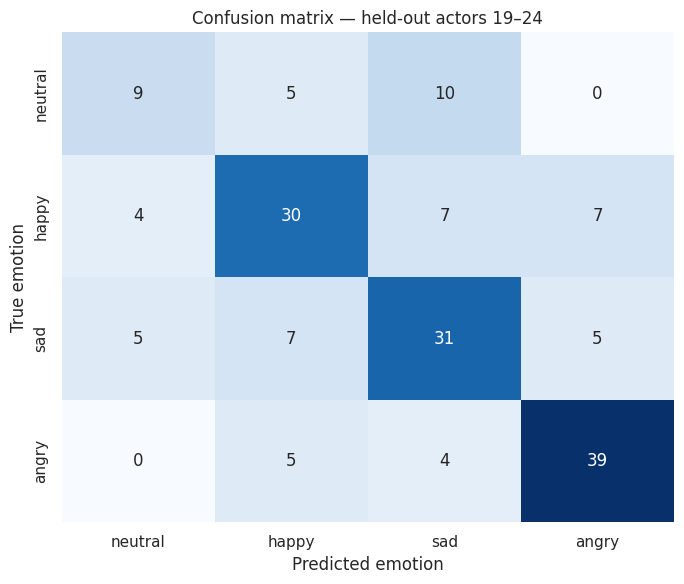


Confusion analysis (generated from the test confusion matrix):
The most frequent error was true neutral predicted as sad (10 clip(s)). The next most frequent was true sad predicted as happy (7 clip(s)). Neutral was most often confused with sad (10 clip(s)). The score is actor-independent: actors 19–24 were excluded from all model fitting and tuning; test accuracy was 0.649 and macro-F1 was 0.617.


In [28]:
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
test_weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Selected model: {best_name}")
print(f"Unseen-actor test accuracy: {test_accuracy:.4f}")
print(f"Unseen-actor test macro-F1: {test_macro_f1:.4f}")
print(f"Unseen-actor test weighted-F1: {test_weighted_f1:.4f}")
print("\nPer-emotion report:")
print(classification_report(y_test, y_pred, labels=EMOTION_ORDER,
                            target_names=EMOTION_ORDER, digits=3, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=EMOTION_ORDER)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER, ax=ax)
ax.set(title="Confusion matrix — held-out actors 19–24",
       xlabel="Predicted emotion", ylabel="True emotion")
plt.tight_layout()
plt.show()

# Generate a short, data-driven confusion analysis rather than inventing explanations.
confusions = [
    (int(cm[i, j]), EMOTION_ORDER[i], EMOTION_ORDER[j])
    for i in range(len(EMOTION_ORDER))
    for j in range(len(EMOTION_ORDER)) if i != j and cm[i, j] > 0
]
confusions.sort(reverse=True)
if confusions:
    count, actual, predicted = confusions[0]
    sentence_1 = f"The most frequent error was true {actual} predicted as {predicted} ({count} clip(s))."
    if len(confusions) > 1:
        count2, actual2, predicted2 = confusions[1]
        sentence_2 = f"The next most frequent was true {actual2} predicted as {predicted2} ({count2} clip(s))."
    else:
        sentence_2 = "No other off-diagonal emotion confusion occurred in this test set."
else:
    sentence_1 = "No off-diagonal emotion confusions occurred in this test set."
    sentence_2 = "All evaluated clips were assigned their correct emotion label."
neutral_i = EMOTION_ORDER.index("neutral")
neutral_errors = cm[neutral_i].copy()
neutral_errors[neutral_i] = 0
if neutral_errors.sum():
    j = int(neutral_errors.argmax())
    sentence_3 = f"Neutral was most often confused with {EMOTION_ORDER[j]} ({int(neutral_errors[j])} clip(s))."
else:
    sentence_3 = "Neutral clips were not misclassified in this held-out test set."
sentence_4 = (f"The score is actor-independent: actors 19–24 were excluded from all model fitting and tuning; "
               f"test accuracy was {test_accuracy:.3f} and macro-F1 was {test_macro_f1:.3f}.")
print("\nConfusion analysis (generated from the test confusion matrix):")
print(" ".join([sentence_1, sentence_2, sentence_3, sentence_4]))

## 6. Save the fitted model and metrics

The model bundle records the feature-column order, sample rate, and class labels so inference uses the same preprocessing assumptions. Kaggle writes these outputs under /kaggle/working; download them from the notebook's Output panel if needed.

In [29]:
import json
import joblib

model_path = Path("/kaggle/working/ravdess_emotion_model.joblib")
metrics_path = Path("/kaggle/working/ravdess_test_metrics.json")
model_bundle = {
    "model": best_model,
    "model_name": best_name,
    "feature_columns": feature_names,
    "sample_rate": SAMPLE_RATE,
    "emotion_order": EMOTION_ORDER,
    "actor_split": {"train_and_cv": list(range(1, 19)), "final_test": list(range(19, 25))},
}
joblib.dump(model_bundle, model_path)
metrics = {
    "selected_model": best_name,
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1),
    "test_clips": int(len(test_df)),
    "test_actors": sorted(int(x) for x in test_df["actor_id"].unique()),
    "cv_best_macro_f1": float(searches[best_name].best_score_),
    "classification_report": classification_report(
        y_test, y_pred, labels=EMOTION_ORDER, target_names=EMOTION_ORDER,
        output_dict=True, zero_division=0,
    ),
}
metrics_path.write_text(json.dumps(metrics, indent=2))
print("Saved model:", model_path)
print("Saved metrics:", metrics_path)

Saved model: /kaggle/working/ravdess_emotion_model.joblib
Saved metrics: /kaggle/working/ravdess_test_metrics.json


In [30]:
# Optional: predict one new WAV using the exact same feature extraction.
def predict_emotion(wav_path, bundle=model_bundle):
    vector = extract_audio_features(wav_path).reshape(1, -1)
    model = bundle["model"]
    label = model.predict(vector)[0]
    result = {"predicted_emotion": label}
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(vector)[0]
        class_names = model.classes_ if hasattr(model, "classes_") else model.named_steps["classifier"].classes_
        result["probabilities"] = {
            str(class_name): float(probability)
            for class_name, probability in zip(class_names, probabilities)
        }
    return result

# Example after uploading/copying a WAV into the notebook environment:
# predict_emotion("/kaggle/working/my_audio.wav")

## Notes for your submission

- Report the printed unseen-actor accuracy, macro-F1, and confusion analysis; do not substitute the cross-validation score for the final test score.
- If you change the actor split or feature set, rerun every cell from feature extraction onward and state the new split clearly.
- This notebook covers data exploration, actor-based evaluation, imbalance handling, and model export. The assessment's separate dashboard, hosting, README, and one-page report still need to be completed if those deliverables are required.